In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'

In [26]:
def pareto_frontier(df, x_col, y_col, x_higher_better=True, y_higher_better=True):
    """
    Compute Pareto-optimal rows for two objectives.
    
    Parameters:
        df: DataFrame
        x_col: Column name for x objective
        y_col: Column name for y objective
        x_higher_better: True if higher x values are better
        y_higher_better: True if higher y values are better
    
    Returns:
        DataFrame of Pareto-optimal rows, sorted by x_col.
    """
    x = df[x_col].values
    y = df[y_col].values
    n = len(x)
    
    is_pareto = np.ones(n, dtype=bool)
    
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            
            if x_higher_better:
                x_ok = x[j] >= x[i]
                x_strict = x[j] > x[i]
            else:
                x_ok = x[j] <= x[i]
                x_strict = x[j] < x[i]
                
            if y_higher_better:
                y_ok = y[j] >= y[i]
                y_strict = y[j] > y[i]
            else:
                y_ok = y[j] <= y[i]
                y_strict = y[j] < y[i]
                
            # j dominates i?
            if x_ok and y_ok and (x_strict or y_strict):
                is_pareto[i] = False
                break
    
    return df[is_pareto].sort_values(x_col, ascending=not x_higher_better)


In [ ]:
data_files = [
    "../results/mgard-sweep/results.jsonl",
    "../results/sperr-sweep/results.jsonl",
    "../results/sz3-sweep/results.jsonl",
    "../results/zfpx-sweep/results.jsonl",
    "../results/zstd-trunc-sweep/results.jsonl"
]

branches = [
    # "AnalysisSiHitElectronsAuxDyn.pt",
    # "AnalysisSiHitElectronsAuxDyn.eta",
    # "AnalysisSiHitElectronsAuxDyn.phi",
    "AnalysisJetsAuxDyn.pt",
    "AnalysisJetsAuxDyn.eta",
    "AnalysisJetsAuxDyn.phi",
]

# columns = [
#     "config.compressor",
#     "config.branches",
#     "results.compression_ratio",
#     "results.psnr"
# ]

df = pd.DataFrame()

for file in data_files:
    raw = pd.read_json(file, lines=True)
    df_tmp = pd.json_normalize(raw.to_dict(orient="records"), sep=".")
    df = pd.concat([df, df_tmp], ignore_index=True)

# Filter for branches
df = df[df["config.branches"].isin(branches)]

# Filter for PSNR
df = df[df["results.psnr"] > 20]

# Filter for compression ratio
# df = df[df["results.compression_ratio"] < 50]

df.sort_values(["config.branches", "results.compression_ratio"])

,config.branches,config.chunk_size,config.compressor,config.compressor_config.mode,config.compressor_config.smoothness,config.compressor_config.tolerance,config.decomp_file,config.input_file,config.iterations,config.normalize,...,config.compressor_config.openmp,config.compressor_config.psnrErrorBound,config.compressor_config.quantbinCnt,config.compressor_config.regression,config.compressor_config.regression2,config.compressor_config.relErrorBound,config.compressor_config.precision,config.compressor_config.rate,config.compressor_config.compressionLevel,config.compressor_config.truncBits
2827,AnalysisJetsAuxDyn.eta,16384,sperr,bitrate,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2828,AnalysisJetsAuxDyn.eta,32768,sperr,bitrate,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2829,AnalysisJetsAuxDyn.eta,65536,sperr,bitrate,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2830,AnalysisJetsAuxDyn.eta,131072,sperr,bitrate,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2831,AnalysisJetsAuxDyn.eta,262144,sperr,bitrate,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6269,AnalysisJetsAuxDyn.pt,16777216,sz3,NaN,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,false,0.000000,65536,true,false,1.000000,NaN,NaN,NaN,NaN
5961,AnalysisJetsAuxDyn.pt,16777216,sz3,NaN,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,false,0.000000,65536,true,false,10.000000,NaN,NaN,NaN,NaN
5950,AnalysisJetsAuxDyn.pt,16777216,sz3,NaN,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,false,0.000000,65536,true,false,100.000000,NaN,NaN,NaN,NaN
6247,AnalysisJetsAuxDyn.pt,16777216,sz3,NaN,NaN,NaN,,DAOD_PHYSLITE.37019878._000009.pool.root.1,5,False,...,false,0.000000,65536,true,false,100.000000,NaN,NaN,NaN,NaN


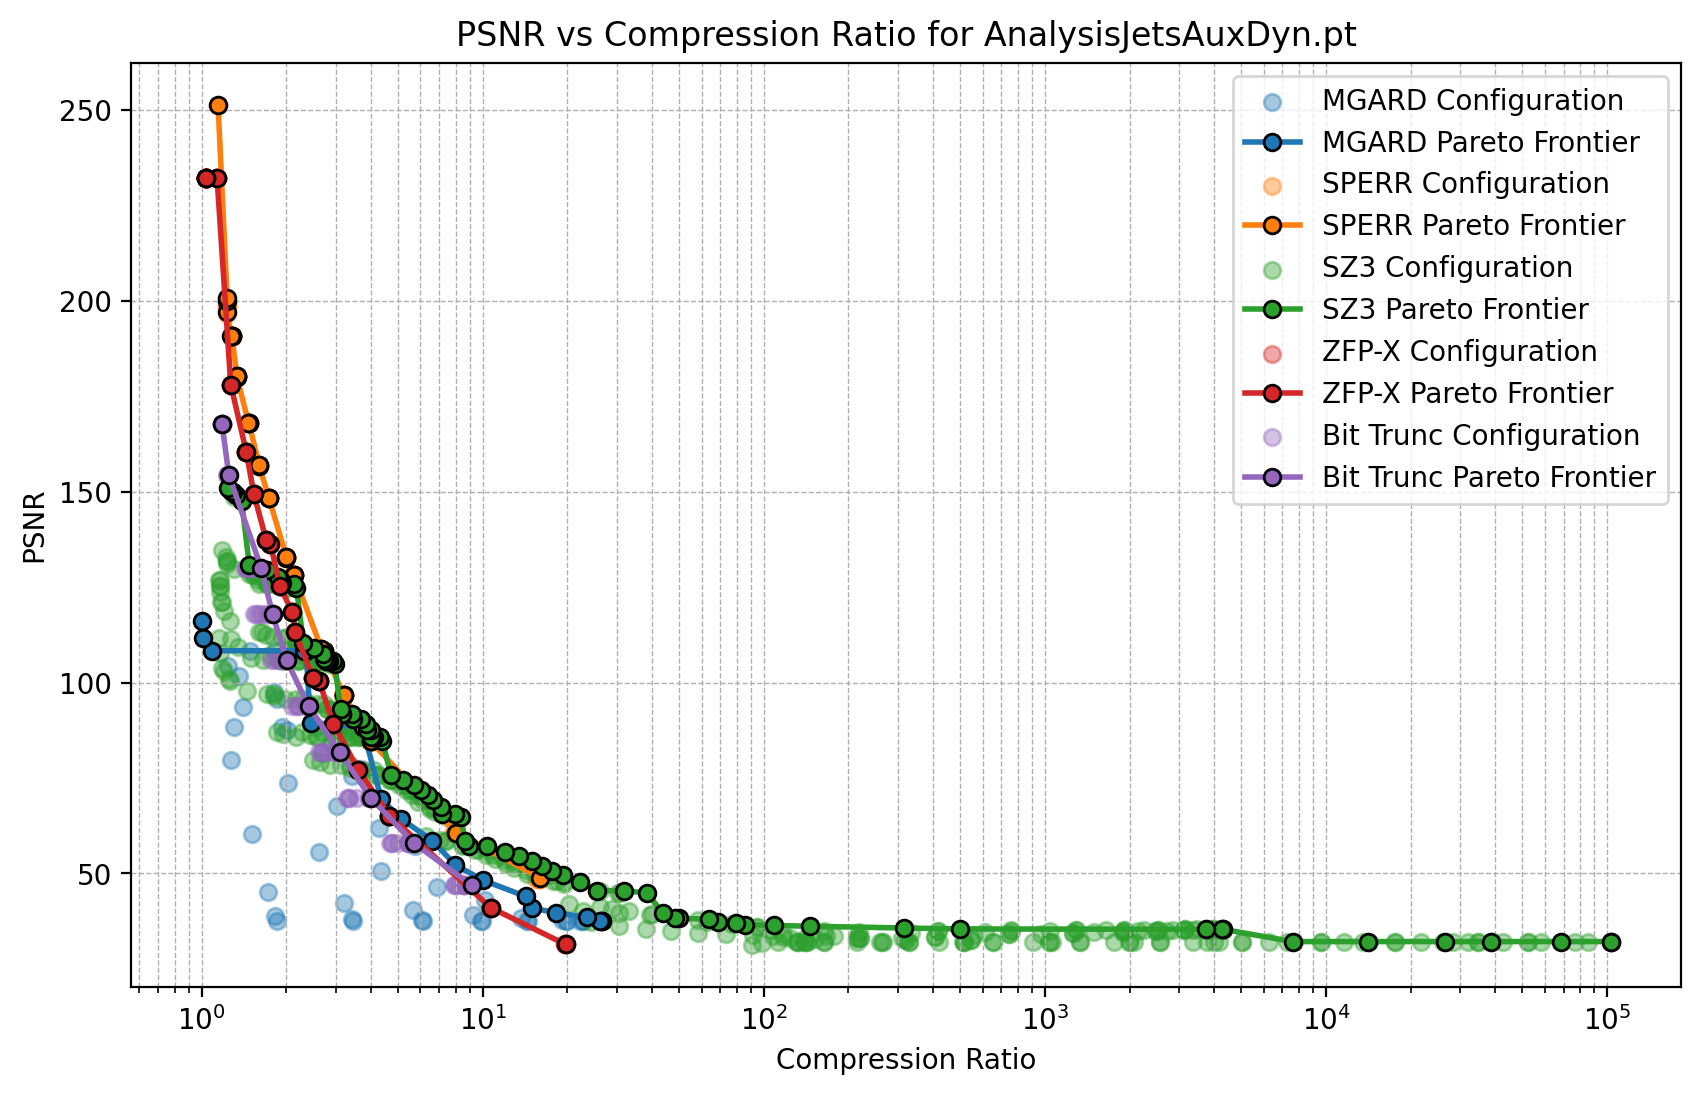

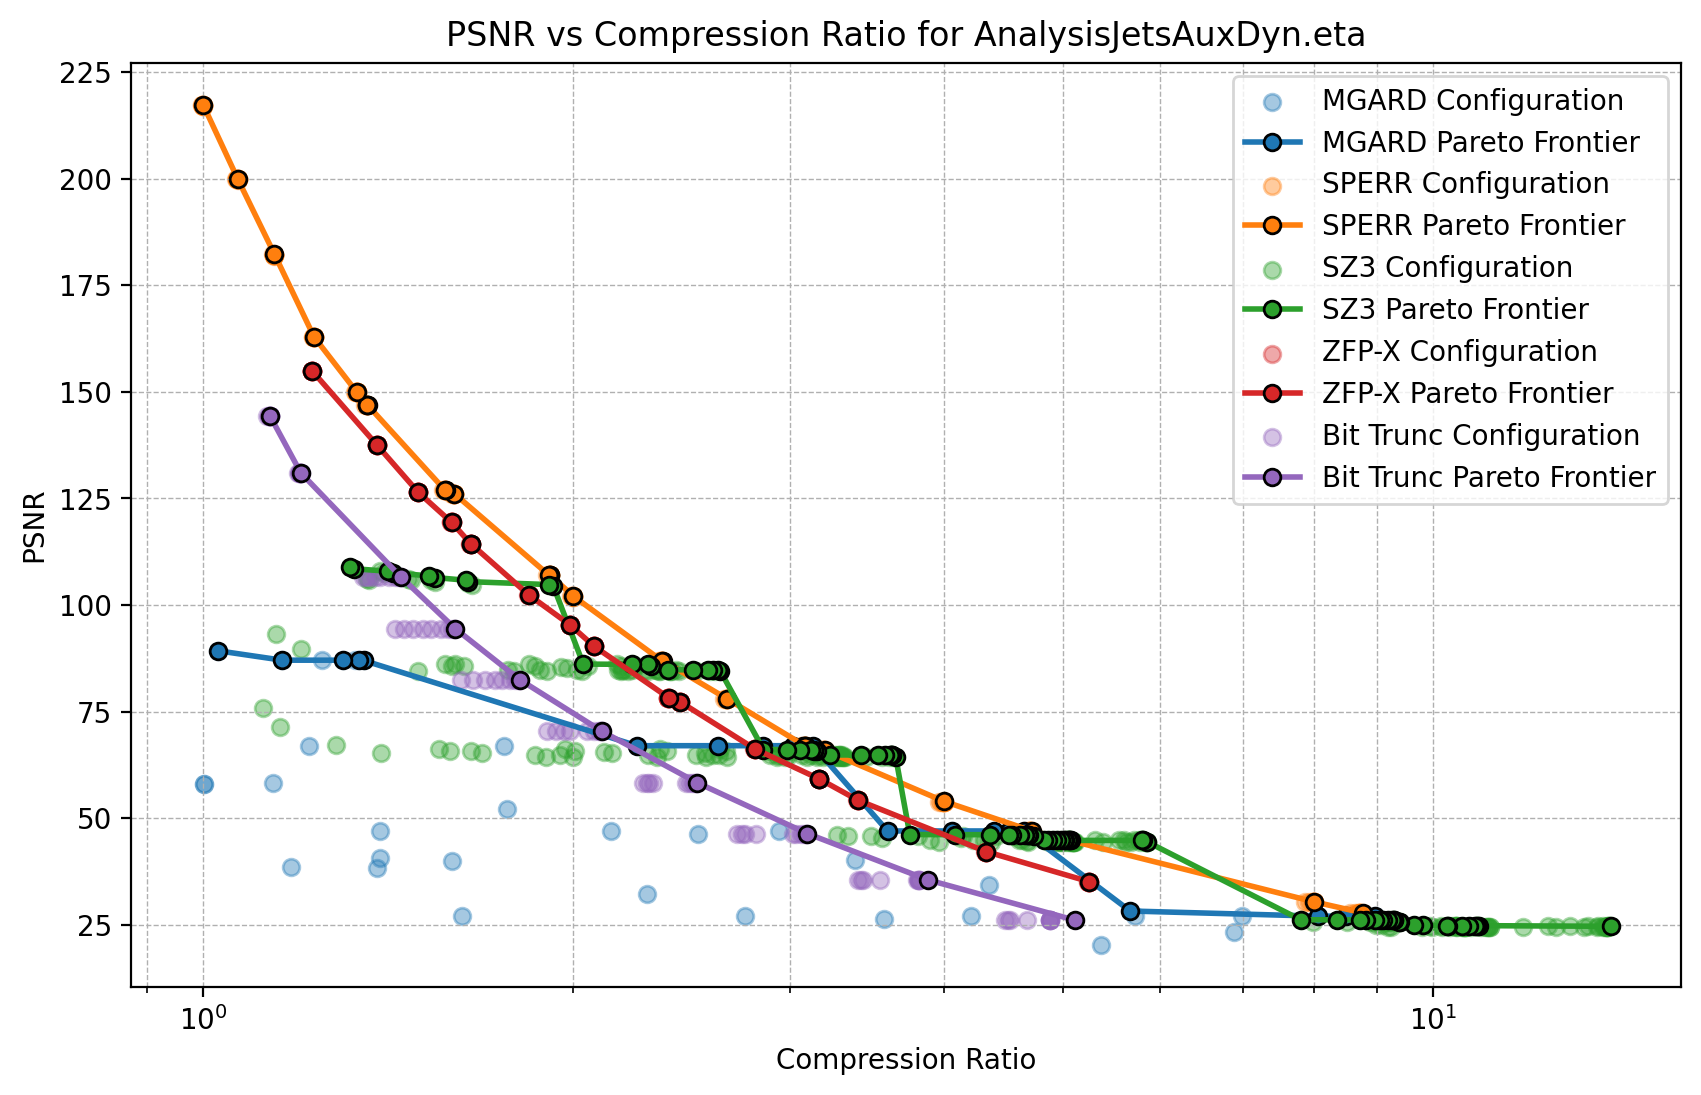

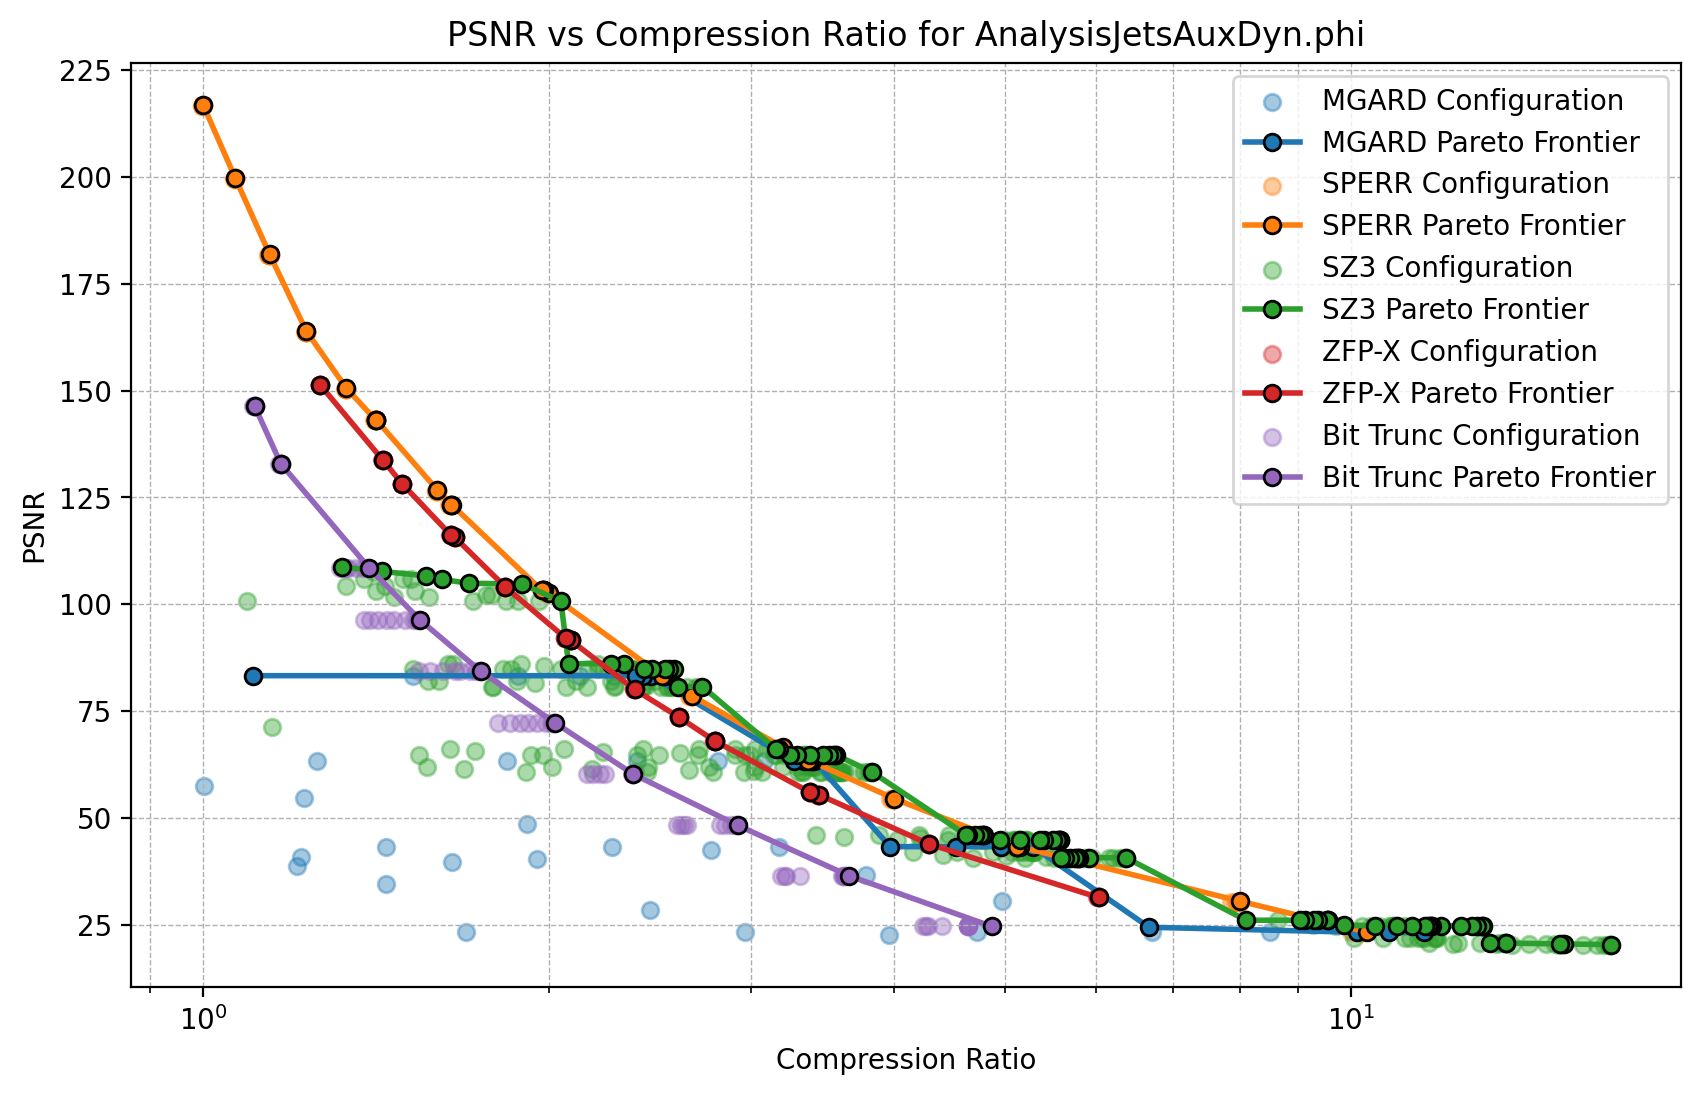

In [ ]:
compressors = df['config.compressor'].unique()

compressor_labels = {
    "mgard": "MGARD",
    "sperr": "SPERR",
    "sz3": "SZ3",
    "zfpx": "ZFP-X",
    "zstd-trunc": "Bit Trunc"
}

frontiers = pd.DataFrame()

for branch in branches:
    plt.figure(figsize=(10, 6))
    for compressor in compressors:
        subset = df[(df['config.compressor'] == compressor) & (df['config.branches'] == branch)]
        
        # Plot PSNR vs Compression Ratio for all configurations
        plt.scatter(
            subset['results.compression_ratio'], 
            subset['results.psnr'], 
            alpha=0.4,
            label=f'{compressor_labels.get(compressor, compressor)} Configuration'
        )
        
        # Compute Pareto frontier for PSNR vs Compression Ratio
        frontier = pareto_frontier(subset, 'results.compression_ratio', 'results.psnr', x_higher_better=True, y_higher_better=True)
        frontiers = pd.concat([frontiers, frontier], ignore_index=True)
        
        # Plot Pareto frontier
        plt.plot(
            frontier['results.compression_ratio'], 
            frontier['results.psnr'], 
            linewidth=2,
            marker='o', markeredgecolor='black',
            label=f'{compressor_labels.get(compressor, compressor)} Pareto Frontier'
        )

    plt.xscale('log')
    # plt.yscale('log')
    plt.xlabel('Compression Ratio')
    plt.ylabel('PSNR')
    plt.title(f'PSNR vs Compression Ratio for {branch}')
    plt.legend()
    plt.grid(True, which="both", ls="--", linewidth=0.5)
    plt.show()

# Write Pareto frontiers to CSV
frontiers.to_csv("../results/pareto_frontiers.csv", index=False)